# Practico 1 - Obtencion, Exploracion y Pretratamiento de Datos
**Curso:** Analisis de Datos - ING0039  
**Integrante:** Facundo Sansalone  
**Dataset:** Garments Worker Productivity (fabrica textil, Bangladesh)  
**Objetivo:** Predecir `actual_productivity` de un equipo en funcion de las caracteristicas del proceso de produccion.

---
## Instalacion de dependencias
Ejecutar solo la primera vez.

In [79]:
# !pip install pandas numpy matplotlib seaborn scikit-learn ydata-profiling

---
## 1. Carga de datos

Dataset con registros diarios de equipos en una fabrica textil de Bangladesh. Cada fila representa un equipo en un dia especifico.

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_colwidth', 90)

df = pd.read_csv('Tema_11.csv')
print('Dataset cargado.')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')

Dataset cargado.
Dimensiones: 1207 filas x 15 columnas


---
## 2. Descripcion de las variables

El dataset tiene 15 variables: **contexto temporal**, **predictoras** y **variable objetivo**.

In [81]:
descripcion = pd.DataFrame({
    'Variable': ['date','quarter','department','day','team',
                 'targeted_productivity','smv','wip','over_time','incentive',
                 'idle_time','idle_men','no_of_style_change','no_of_workers','actual_productivity'],
    'Tipo': ['Fecha','Categorica','Categorica','Categorica','Discreta',
             'Continua','Continua','Continua','Continua','Continua',
             'Continua','Discreta','Discreta','Continua','Continua'],
    'Rol': ['Contexto','Contexto','Predictora','Predictora','Predictora',
            'Predictora','Predictora','Predictora','Predictora','Predictora',
            'Predictora','Predictora','Predictora','Predictora','OBJETIVO'],
    'Descripcion': [
        'Fecha del registro (MM/DD/YYYY)',
        'Porcion del mes: Quarter1 a Quarter4',
        'Departamento: sewing (costura) o finishing (acabado)',
        'Dia de la semana del registro',
        'Numero del equipo de trabajo (1-12)',
        'Meta de productividad asignada por la autoridad (0-1)',
        'Standard Minute Value: tiempo estandar para la tarea (min)',
        'Work In Progress: unidades iniciadas pero no terminadas',
        'Horas extra trabajadas por el equipo (minutos)',
        'Incentivo economico otorgado al equipo (BDT)',
        'Tiempo de interrupcion de la produccion (minutos)',
        'Trabajadores inactivos durante interrupciones',
        'Cantidad de cambios en el diseno del producto',
        'Total de trabajadores en el equipo ese dia',
        'Productividad real del equipo (0-1) - VARIABLE A PREDECIR'
    ]
})
descripcion

,Variable,Tipo,Rol,Descripcion
0,date,Fecha,Contexto,Fecha del registro (MM/DD/YYYY)
1,quarter,Categorica,Contexto,Porcion del mes: Quarter1 a Quarter4
2,department,Categorica,Predictora,Departamento: sewing (costura) o finishing (acabado)
3,day,Categorica,Predictora,Dia de la semana del registro
4,team,Discreta,Predictora,Numero del equipo de trabajo (1-12)
5,targeted_productivity,Continua,Predictora,Meta de productividad asignada por la autoridad (0-1)
6,smv,Continua,Predictora,Standard Minute Value: tiempo estandar para la tarea (min)
7,wip,Continua,Predictora,Work In Progress: unidades iniciadas pero no terminadas
8,over_time,Continua,Predictora,Horas extra trabajadas por el equipo (minutos)
9,incentive,Continua,Predictora,Incentivo economico otorgado al equipo (BDT)


---
## 3. Analisis Exploratorio de Datos (EDA)

### 3a. Cantidad de filas y columnas
Verificamos las dimensiones y los tipos de dato que pandas asigno a cada columna.

In [82]:
filas, columnas = df.shape
print(f'Filas:    {filas}')
print(f'Columnas: {columnas}')
print()
print('Tipos de dato (object=texto, float64=decimal):')
print(df.dtypes)

Filas:    1207
Columnas: 15

Tipos de dato (object=texto, float64=decimal):
date                      object
quarter                   object
department                object
day                       object
team                      object
targeted_productivity    float64
smv                      float64
wip                      float64
over_time                float64
incentive                float64
idle_time                float64
idle_men                 float64
no_of_style_change       float64
no_of_workers            float64
actual_productivity      float64
dtype: object


### 3b. Primeras 5 filas
Vista previa del dataset sin procesar para ver su estructura real.

In [83]:
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8.0,0.80,26.16,1108.0,7080.0,98.0,0.0,0.0,0.0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1.0,0.75,3.94,NaN,960.0,0.0,0.0,0.0,0.0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,0.0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,NaN,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6.0,0.80,25.90,NaN,1920.0,50.0,0.0,0.0,0.0,56.0,NaN


In [84]:
# Estadisticas descriptivas: media, desvio, min, max, cuartiles
df.describe()

,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1146.000000,1148.000000,668.000000,1149.000000,1147.000000,1146.000000,1147.000000,1147.000000,1147.000000,1147.000000
mean,0.728988,20.671272,1202.133234,5862.654482,38.871840,0.762653,0.326940,0.151700,34.598518,0.852642
std,0.099195,55.051234,1866.755181,13146.200215,163.488076,12.988774,3.034473,0.429704,22.189488,1.122498
min,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,0.700000,3.940000,783.750000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650899
50%,0.750000,15.260000,1043.000000,4080.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.779792
75%,0.800000,24.260000,1256.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850413
max,0.800000,545.600000,23122.000000,129600.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,11.204375


### 3c. Datos faltantes y duplicados
Cuantificamos los valores faltantes por columna y las filas duplicadas.

In [85]:
# Datos faltantes
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Valores faltantes': nulos, 'Porcentaje (%)': pct_nulos})
resumen_nulos = resumen_nulos[resumen_nulos['Valores faltantes'] > 0]\
                .sort_values('Porcentaje (%)', ascending=False)
print('=== Datos faltantes por columna ===')
print(resumen_nulos)
print(f'\nTotal celdas faltantes: {nulos.sum()}')

=== Datos faltantes por columna ===
                       Valores faltantes  Porcentaje (%)
wip                                  539           44.66
date                                  62            5.14
day                                   61            5.05
targeted_productivity                 61            5.05
idle_time                             61            5.05
quarter                               60            4.97
department                            60            4.97
incentive                             60            4.97
idle_men                              60            4.97
no_of_style_change                    60            4.97
no_of_workers                         60            4.97
actual_productivity                   60            4.97
team                                  59            4.89
smv                                   59            4.89
over_time                             58            4.81

Total celdas faltantes: 1380


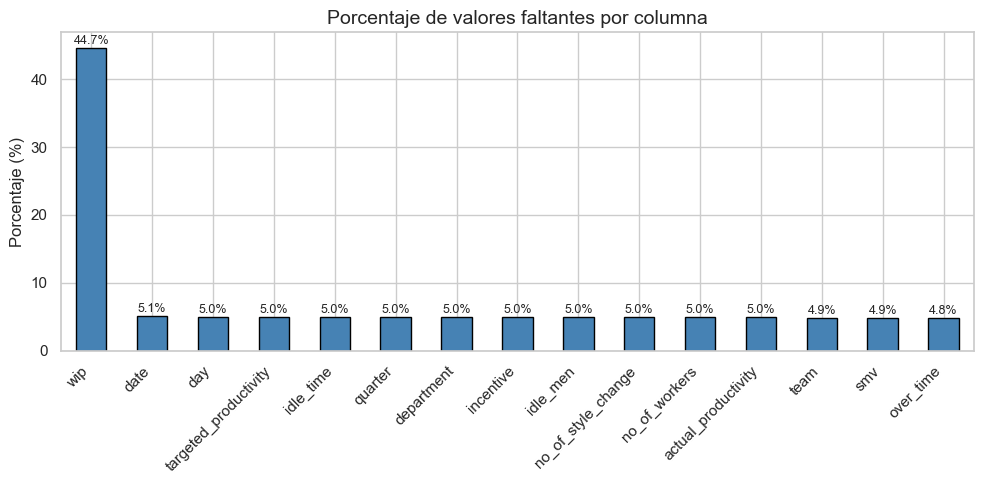

In [86]:
fig, ax = plt.subplots(figsize=(10, 5))
resumen_nulos['Porcentaje (%)'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Porcentaje de valores faltantes por columna', fontsize=14)
ax.set_ylabel('Porcentaje (%)')
ax.set_xticklabels(resumen_nulos.index, rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.1),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [87]:
# Datos duplicados
n_dup = df.duplicated().sum()
pct_dup = round(n_dup / len(df) * 100, 2)
print(f'Filas duplicadas: {n_dup} ({pct_dup}% del total)')
if n_dup > 0:
    print('\nEjemplos de duplicados:')
    print(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(6))

Filas duplicadas: 10 (0.83% del total)

Ejemplos de duplicados:
           date   quarter department       day  team  targeted_productivity  \
188   1/11/2015  Quarter2     sweing    Sunday  11.0                    0.6   
1197  1/11/2015  Quarter2     sweing    Sunday  11.0                    0.6   
180   1/11/2015  Quarter2     sweing    Sunday   6.0                    0.8   
1198  1/11/2015  Quarter2     sweing    Sunday   6.0                    0.8   
283   1/17/2015  Quarter3     sweing  Saturday   6.0                    0.8   
1203  1/17/2015  Quarter3     sweing  Saturday   6.0                    0.8   

        smv     wip  over_time  incentive  idle_time  idle_men  \
188   12.52   831.0     9540.0       30.0        0.0       0.0   
1197  12.52   831.0     9540.0       30.0        0.0       0.0   
180   11.41   887.0     5490.0       50.0        0.0       0.0   
1198  11.41   887.0     5490.0       50.0        0.0       0.0   
283   11.41  1067.0     5490.0       63.0        0.0

### 3d. Posibles motivos de datos faltantes

- **Estructural**: no aplica en ese contexto (wip en finishing)
- **Derivable**: recuperable desde otra columna (day desde date)
- **Error de registro**: deberia existir pero no fue cargado
- **Posible cero**: el faltante equivale a ausencia del fenomeno

In [88]:
# Analisis de wip por departamento
temp = df.copy()
temp['department'] = temp['department'].str.strip()
print('Nulos de wip por departamento:')
print(temp.groupby('department')['wip'].agg(
    total='count',
    faltantes=lambda x: x.isnull().sum(),
    pct=lambda x: f'{x.isnull().mean()*100:.1f}%'
))
print('\nConclusion: los nulos de wip son casi exclusivos de finishing,')
print('donde no hay produccion intermedia por definicion del flujo.')

Nulos de wip por departamento:
            total  faltantes     pct
department                          
finishing       0        477  100.0%
sweing        642         28    4.2%

Conclusion: los nulos de wip son casi exclusivos de finishing,
donde no hay produccion intermedia por definicion del flujo.


In [89]:
motivos = pd.DataFrame([
    ('wip',                   'Estructural',    'En finishing no hay WIP. En sewing: error de registro.'),
    ('date',                  'Error registro', 'Fecha no ingresada. Impide derivar quarter y day.'),
    ('quarter',               'Derivable',      'Calculable desde date (semana del mes).'),
    ('day',                   'Derivable',      'Calculable con pandas desde date.'),
    ('department',            'Error registro', 'Campo obligatorio. Sin el, no se clasifica el registro.'),
    ('targeted_productivity', 'Error registro', 'Meta no registrada. Imputable con mediana del dpto/dia.'),
    ('incentive',             'Posible cero',   'Sin incentivo ese dia; nulo equivale a 0.'),
    ('idle_time',             'Posible cero',   'Sin interrupcion de produccion; nulo equivale a 0.'),
    ('idle_men',              'Posible cero',   'Sin inactividad; nulo equivale a 0.'),
    ('no_of_style_change',    'Posible cero',   'Sin cambios de estilo; nulo equivale a 0.'),
    ('no_of_workers',         'Error registro', 'Siempre debe existir. Imputable con mediana del equipo.'),
    ('actual_productivity',   'Sin medicion',   'Variable objetivo no medida. No imputable: fila se elimina.'),
], columns=['Columna', 'Tipo de faltante', 'Motivo probable'])
motivos[motivos['Columna'].isin(resumen_nulos.index)]

,Columna,Tipo de faltante,Motivo probable
0,wip,Estructural,En finishing no hay WIP. En sewing: error de registro.
1,date,Error registro,Fecha no ingresada. Impide derivar quarter y day.
2,quarter,Derivable,Calculable desde date (semana del mes).
3,day,Derivable,Calculable con pandas desde date.
4,department,Error registro,"Campo obligatorio. Sin el, no se clasifica el registro."
5,targeted_productivity,Error registro,Meta no registrada. Imputable con mediana del dpto/dia.
6,incentive,Posible cero,Sin incentivo ese dia; nulo equivale a 0.
7,idle_time,Posible cero,Sin interrupcion de produccion; nulo equivale a 0.
8,idle_men,Posible cero,Sin inactividad; nulo equivale a 0.
9,no_of_style_change,Posible cero,Sin cambios de estilo; nulo equivale a 0.


### 3e. Valores unicos de variables discretas y categoricas
Listamos todos los valores posibles para detectar inconsistencias como espacios o typos.

In [90]:
vars_discretas = ['quarter', 'department', 'day', 'team', 'no_of_style_change', 'idle_men']

for col in vars_discretas:
    conteo = df[col].value_counts(dropna=True).sort_index()
    print(f'--- {col} ({len(conteo)} valores unicos) ---')
    print(conteo.to_frame(name='Frecuencia').T)
    print()

--- quarter (5 valores unicos) ---
quarter     Quarter1  Quarter2  Quarter3  Quarter4  Quarter5
Frecuencia       339       320       203       246        39

--- department (3 valores unicos) ---
department  finishing  finishing   sweing
Frecuencia        233         244     670

--- day (6 valores unicos) ---
day         Monday  Saturday  Sunday  Thursday  Tuesday  Wednesday
Frecuencia     190       177     194       190      191        204

--- team (13 valores unicos) ---
team        1.0  10.0  11.0  12.0  2.0  3.0  4.0  5.0  6.0  7.0  8.0  9.0  \
Frecuencia   99    96    84    94   99   87  103   84   96   90  106   98   

team        invalid_value  
Frecuencia             12  

--- no_of_style_change (3 valores unicos) ---
no_of_style_change   0.0  1.0  2.0
Frecuencia          1005  110   32

--- idle_men (9 valores unicos) ---
idle_men    0.0   10.0  15.0  20.0  25.0  30.0  35.0  40.0  45.0
Frecuencia  1131     3     3     3     1     2     2     1     1



### 3f. Cuantificacion de valores unicos e histogramas
Tabla resumen e histogramas para entender la distribucion de cada variable.

In [91]:
# Tabla resumen de valores unicos por variable discreta
resumen_disc = pd.DataFrame({
    'Variable':                     vars_discretas,
    'Valores unicos':               [df[c].nunique() for c in vars_discretas],
    'Valores unicos (sin nulos)':   [df[c].dropna().nunique() for c in vars_discretas],
    'Nulos':                        [df[c].isnull().sum() for c in vars_discretas]
})
print(resumen_disc.to_string(index=False))

          Variable  Valores unicos  Valores unicos (sin nulos)  Nulos
           quarter               5                           5     60
        department               3                           3     60
               day               6                           6     61
              team              13                          13     59
no_of_style_change               3                           3     60
          idle_men               9                           9     60


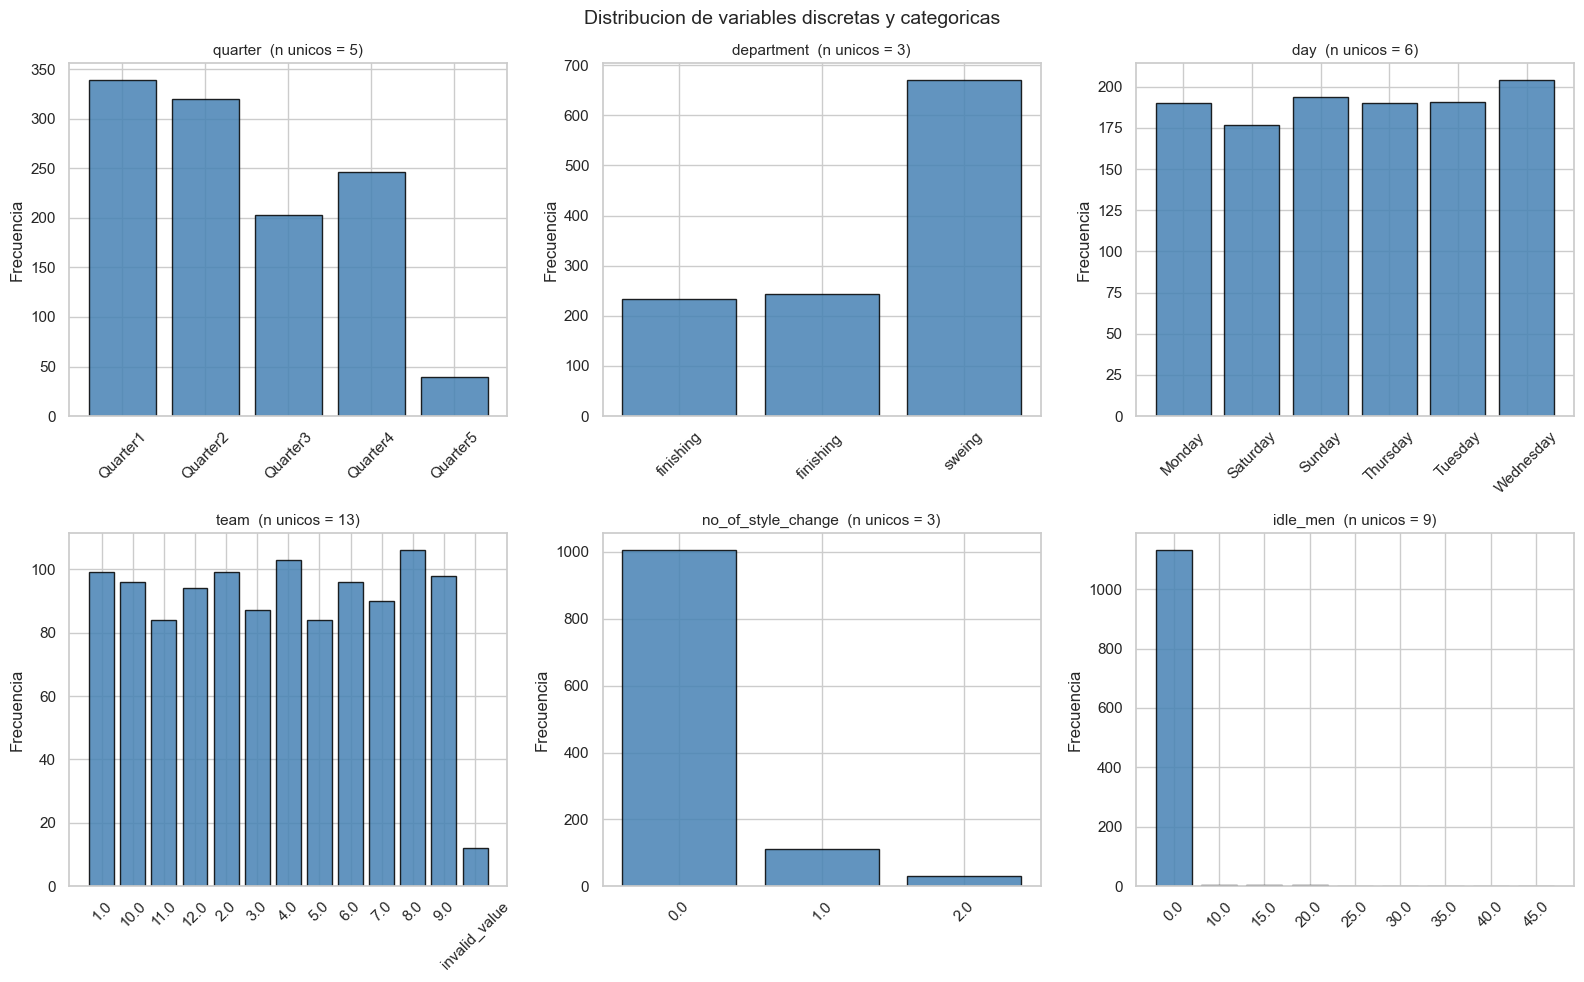

In [92]:
# Histogramas de variables discretas y categoricas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(vars_discretas):
    conteo = df[col].value_counts().sort_index()
    axes[i].bar(conteo.index.astype(str), conteo.values,
                color='steelblue', edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{col}  (n unicos = {df[col].nunique()})', fontsize=11)
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Distribucion de variables discretas y categoricas', fontsize=14)
plt.tight_layout()
plt.show()

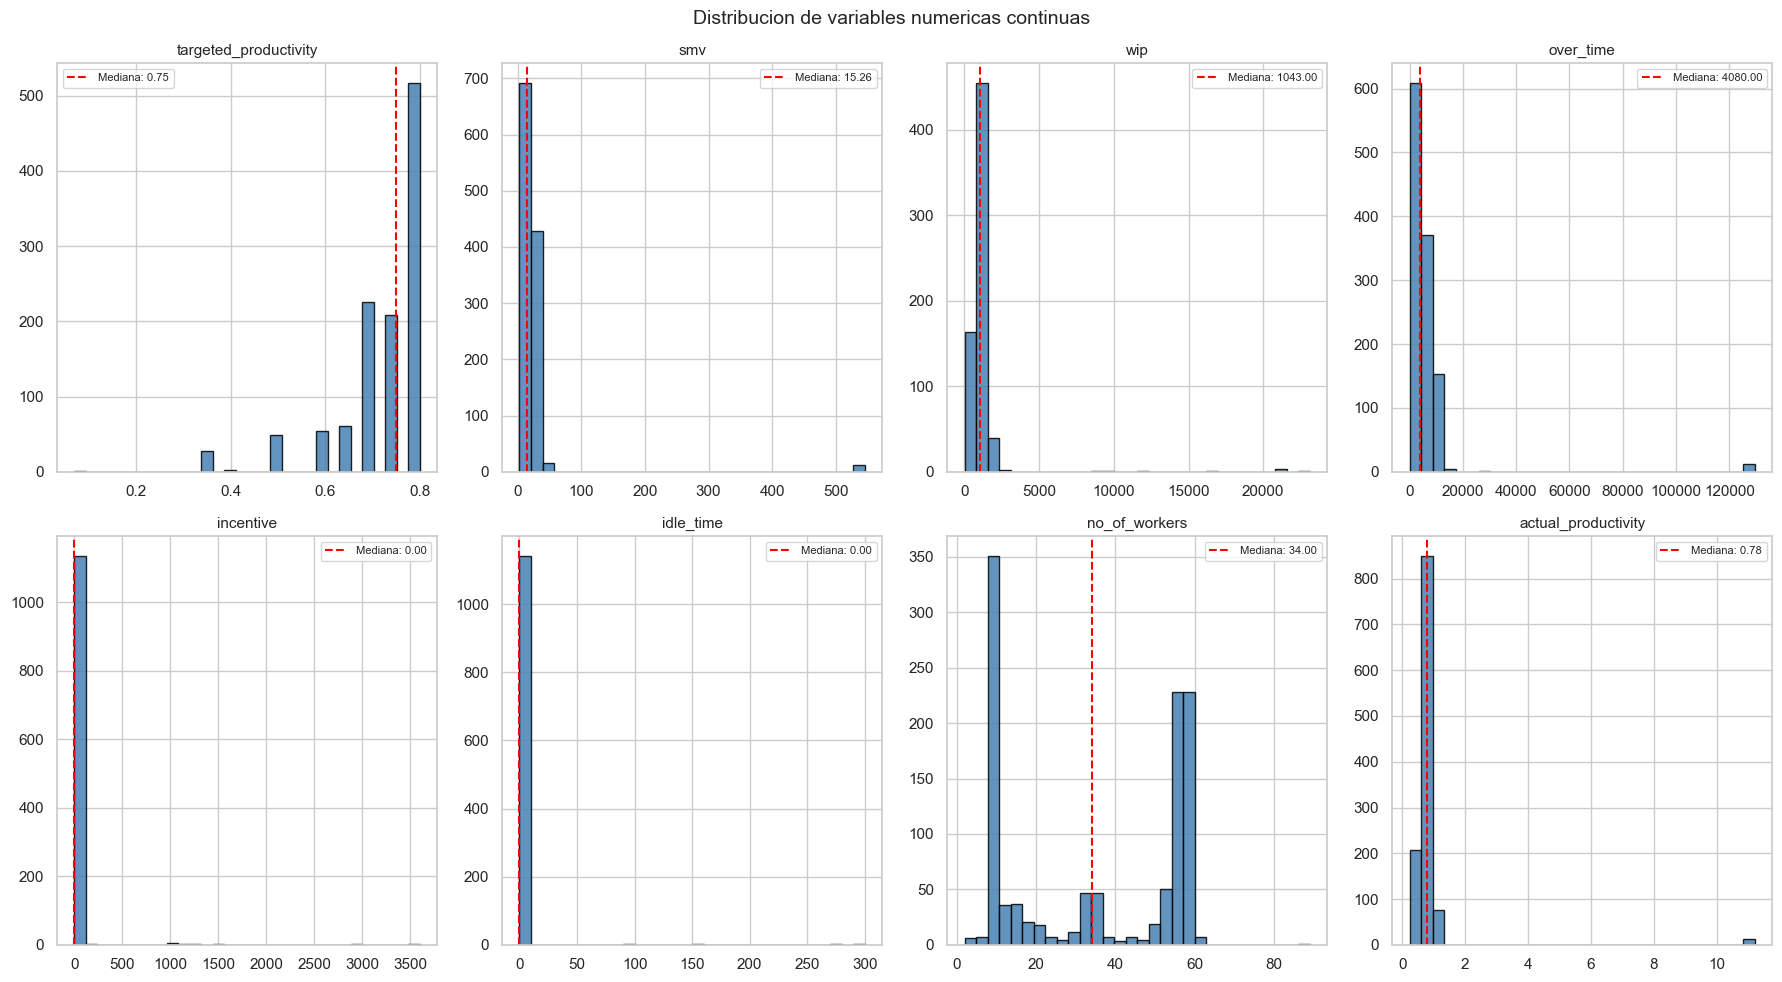

In [93]:
# Histogramas de variables continuas con linea de mediana
vars_continuas = ['targeted_productivity','smv','wip','over_time',
                  'incentive','idle_time','no_of_workers','actual_productivity']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(vars_continuas):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.85)
    axes[i].axvline(data.median(), color='red', linestyle='--', lw=1.5,
                    label=f'Mediana: {data.median():.2f}')
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)
plt.suptitle('Distribucion de variables numericas continuas', fontsize=14)
plt.tight_layout()
plt.show()

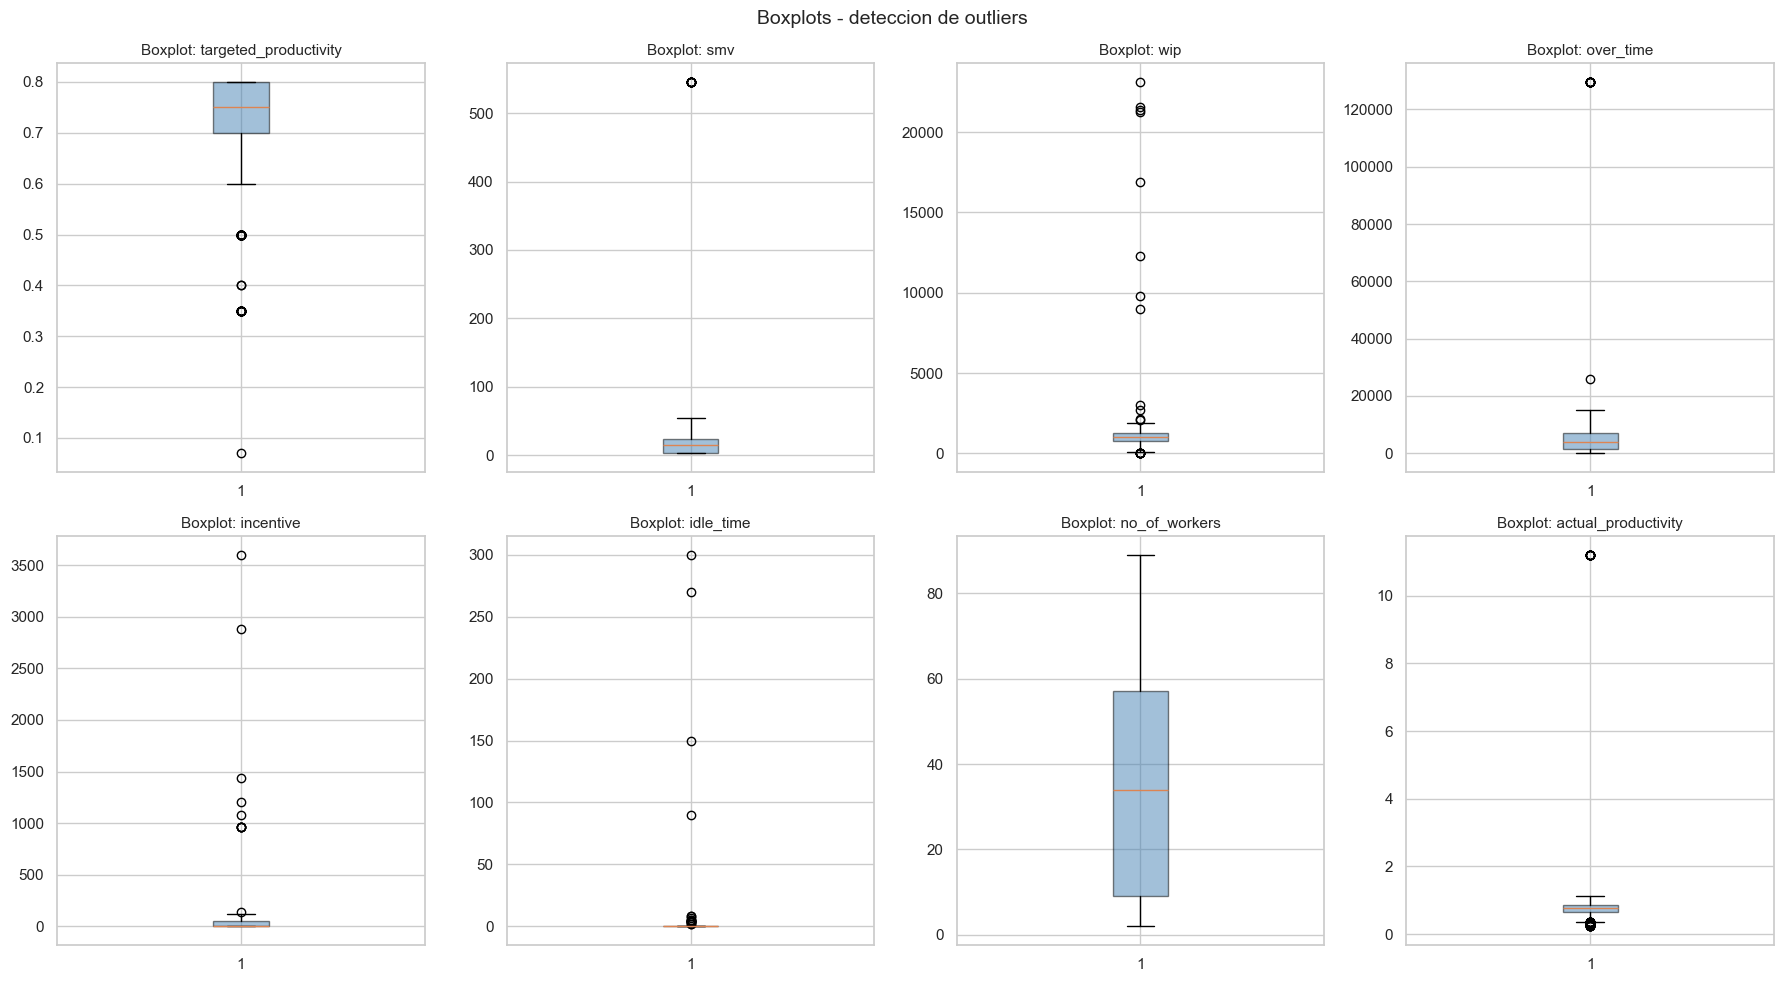

In [94]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(vars_continuas):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[i].set_title(f'Boxplot: {col}', fontsize=11)
plt.suptitle('Boxplots - deteccion de outliers', fontsize=14)
plt.tight_layout()
plt.show()

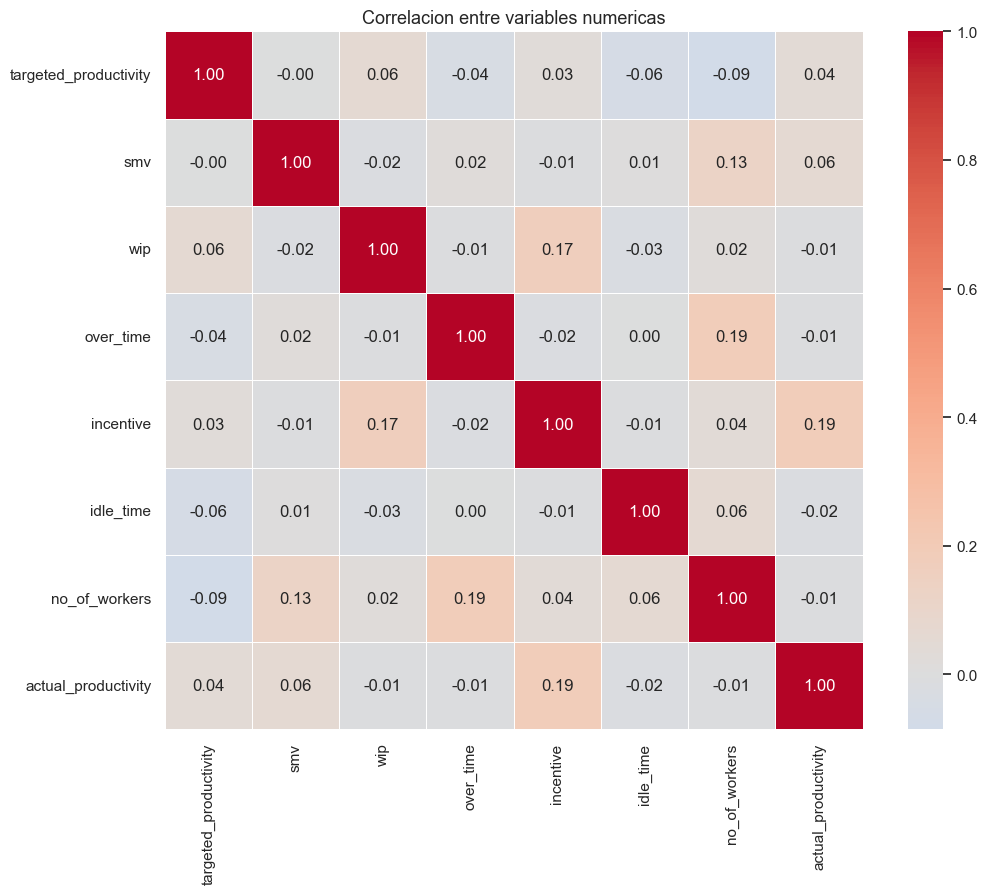

In [95]:
# Mapa de correlacion: buscar variables relacionadas con actual_productivity
corr = df[vars_continuas].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.4)
plt.title('Correlacion entre variables numericas', fontsize=13)
plt.tight_layout()
plt.show()

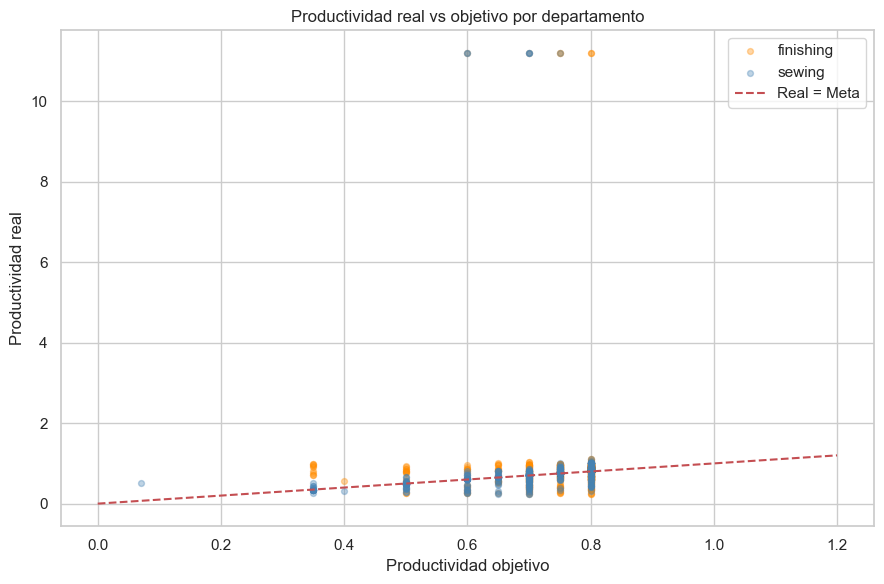

In [96]:
# Productividad real vs meta por departamento
# Linea roja: real == meta; puntos arriba = superaron la meta
t = df.dropna(subset=['department','actual_productivity','targeted_productivity']).copy()
t['dept_clean'] = t['department'].str.strip().replace('sweing','sewing')

fig, ax = plt.subplots(figsize=(9, 6))
for dept, grp in t.groupby('dept_clean'):
    color = 'steelblue' if dept == 'sewing' else 'darkorange'
    ax.scatter(grp['targeted_productivity'], grp['actual_productivity'],
               label=dept, alpha=0.35, s=18, color=color)
ax.plot([0, 1.2], [0, 1.2], 'r--', lw=1.5, label='Real = Meta')
ax.set_xlabel('Productividad objetivo')
ax.set_ylabel('Productividad real')
ax.set_title('Productividad real vs objetivo por departamento')
ax.legend()
plt.tight_layout()
plt.show()

### 3g. Deteccion de datos inconsistentes

Son valores que **existen** (no nulos) pero son incorrectos: texto en campo numerico, fuera de rango, outliers imposibles.

In [97]:
# [1] Valor no numerico en 'team'
invalidos = df[pd.to_numeric(df['team'], errors='coerce').isnull() & df['team'].notna()]
print(f'[1] Valores no numericos en team: {len(invalidos)}')
print(invalidos[['date','department','day','team']])

[1] Valores no numericos en team: 12
          date  department        day           team
34    1/3/2015      sweing   Saturday  invalid_value
104   1/7/2015  finishing   Wednesday  invalid_value
229  1/13/2015         NaN    Tuesday  invalid_value
372  1/22/2015  finishing    Thursday  invalid_value
378  1/22/2015      sweing   Thursday  invalid_value
384  1/22/2015  finishing    Thursday  invalid_value
438  1/26/2015  finishing      Monday  invalid_value
537  1/31/2015      sweing   Saturday  invalid_value
547   2/1/2015  finishing      Sunday  invalid_value
633   2/5/2015      sweing   Thursday  invalid_value
771  2/15/2015   finishing     Sunday  invalid_value
923  2/25/2015   finishing  Wednesday  invalid_value


In [98]:
# [2] Typos y espacios en 'department'
print('[2] Valores unicos en department (SIN limpiar):')
print(df['department'].value_counts())
print('\nProblema: trailing space en "finishing " y typo "sweing" vs "sewing"')

[2] Valores unicos en department (SIN limpiar):
department
sweing        670
finishing     244
finishing     233
Name: count, dtype: int64

Problema: trailing space en "finishing " y typo "sweing" vs "sewing"


In [99]:
# [3] actual_productivity fuera del rango [0, 1]
fuera = df[(df['actual_productivity'] < 0) | (df['actual_productivity'] > 1)]
print(f'[3] actual_productivity fuera de [0,1]: {len(fuera)} registros')
if len(fuera) > 0:
    print(fuera[['date','department','team','actual_productivity']])

[3] actual_productivity fuera de [0,1]: 48 registros
           date  department  team  actual_productivity
55     1/4/2015      sweing   3.0            11.204375
188   1/11/2015      sweing  11.0            11.204375
212   1/12/2015  finishing    NaN            11.204375
337   1/20/2015  finishing    NaN             1.033570
371   1/22/2015  finishing    7.0            11.204375
437   1/26/2015  finishing    3.0            11.204375
456   1/27/2015      sweing   2.0             1.000230
477   1/28/2015      sweing   2.0             1.000230
478   1/28/2015      sweing   3.0             1.000230
498   1/29/2015      sweing   2.0             1.000230
518   1/31/2015      sweing   3.0             1.000457
519   1/31/2015      sweing   2.0             1.000230
542    2/1/2015  finishing    8.0             1.011562
543    2/1/2015      sweing   2.0             1.000671
544    2/1/2015      sweing   1.0             1.000402
561    2/2/2015      sweing   1.0             1.000602
580    2/3/2

In [100]:
# [4] smv con valor extremo (normal: 2-30 min; outlier: 545.6 min)
print('[4] smv > 100 minutos:')
print(df[df['smv'] > 100][['date','department','team','smv']])
smv_normal = df[df['smv'] <= 100]['smv']
print(f'Mediana smv normal: {smv_normal.median():.2f} min')

[4] smv > 100 minutos:
           date  department           team    smv
25     1/3/2015      sweing            3.0  545.6
167   1/10/2015  finishing             NaN  545.6
211   1/12/2015      sweing           11.0  545.6
284   1/17/2015      sweing           12.0  545.6
352   1/21/2015  finishing             4.0  545.6
437   1/26/2015  finishing             3.0  545.6
771   2/15/2015   finishing  invalid_value  545.6
821   2/17/2015      sweing            2.0  545.6
839         NaN   finishing            9.0  545.6
1135   3/9/2015      sweing           12.0  545.6
1161  3/10/2015   finishing           11.0  545.6
1194  3/11/2015         NaN            7.0  545.6
Mediana smv normal: 15.26 min


In [101]:
# [5] over_time imposible (129600 min = 90 dias de overtime en un dia)
print('[5] over_time > 25000 minutos:')
print(df[df['over_time'] > 25000][['date','department','team','over_time']])
ot_normal = df[df['over_time'] <= 25000]['over_time']
print(f'Percentil 99 normal: {ot_normal.quantile(0.99):.0f} min')

[5] over_time > 25000 minutos:
           date  department  team  over_time
14     1/1/2015  finishing    8.0   129600.0
146    1/8/2015      sweing  11.0    25920.0
388   1/22/2015      sweing   8.0   129600.0
491   1/28/2015  finishing    8.0   129600.0
511   1/29/2015  finishing    2.0   129600.0
832   2/18/2015      sweing   7.0   129600.0
840   2/18/2015      sweing   2.0   129600.0
853   2/19/2015      sweing   3.0   129600.0
935   2/25/2015      sweing  10.0   129600.0
1020   3/2/2015      sweing  10.0   129600.0
1072   3/5/2015   finishing   1.0   129600.0
1191  3/11/2015      sweing   7.0   129600.0
1193  3/11/2015   finishing   8.0   129600.0
Percentil 99 normal: 10620 min


In [102]:
# [6] Valores negativos en columnas que deben ser >= 0
cols_pos = ['smv','wip','over_time','incentive','idle_time','idle_men','no_of_workers']
print('[6] Valores negativos:')
neg_found = False
for col in cols_pos:
    n = (df[col] < 0).sum()
    if n > 0:
        print(f'  {col}: {n}')
        neg_found = True
if not neg_found:
    print('  Ninguno detectado.')

[6] Valores negativos:
  Ninguno detectado.


In [103]:
# Tabla resumen de inconsistencias
pd.DataFrame([
    ('team = invalid_value',        '1 fila',     'Texto en columna numerica'),
    ('department: espacio + typo',  'Todo el set','Trailing space y sweing vs sewing'),
    ('smv = 545.6',                 '1 fila',     'Outlier extremo (~28x la mediana)'),
    ('over_time = 129600 min',      '1 fila',     'Equivale a 90 dias laborales, imposible'),
    ('Valores negativos',           '0 filas',    'No detectados'),
], columns=['Inconsistencia','Alcance','Descripcion'])

,Inconsistencia,Alcance,Descripcion
0,team = invalid_value,1 fila,Texto en columna numerica
1,department: espacio + typo,Todo el set,Trailing space y sweing vs sewing
2,smv = 545.6,1 fila,Outlier extremo (~28x la mediana)
3,over_time = 129600 min,1 fila,"Equivale a 90 dias laborales, imposible"
4,Valores negativos,0 filas,No detectados


---
## 4. Limpieza de datos

**Decisiones tomadas:**
- **Corregir**: errores de formato y typos (department, team, smv, over_time)
- **Imputar con mediana del grupo**: wip, no_of_workers, targeted_productivity
- **Imputar con 0**: incentive, idle_time, idle_men, no_of_style_change (faltante = ausencia del fenomeno)
- **Eliminar fila**: cuando el dato critico no es recuperable (team, department, actual_productivity nulos)

Todo sobre una **copia** del dataset original.

In [104]:
df_clean = df.copy()
print(f'Filas antes de limpieza: {len(df_clean)}')

Filas antes de limpieza: 1207


In [105]:
# 4.1 Limpiar department: eliminar espacios y corregir typo
df_clean['department'] = df_clean['department'].str.strip().replace('sweing','sewing')
print('department post-limpieza:', df_clean['department'].unique())

department post-limpieza: ['sewing' 'finishing' nan]


In [106]:
# 4.2 Limpiar team: 'invalid_value' -> NaN via conversion numerica
df_clean['team'] = pd.to_numeric(df_clean['team'], errors='coerce')
print(f'Nulos en team tras conversion: {df_clean["team"].isnull().sum()}')

Nulos en team tras conversion: 71


In [107]:
# 4.3 Convertir date a datetime y recuperar day donde sea posible
df_clean['date'] = pd.to_datetime(df_clean['date'], format='%m/%d/%Y', errors='coerce')
dias = {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',
        4:'Friday',5:'Saturday',6:'Sunday'}
mask = df_clean['day'].isnull() & df_clean['date'].notna()
df_clean.loc[mask,'day'] = df_clean.loc[mask,'date'].dt.dayofweek.map(dias)
print(f'Valores de day recuperados desde date: {mask.sum()}')

Valores de day recuperados desde date: 59


In [108]:
# 4.4 Derivar quarter desde date donde sea posible
# quarter = porcion del mes (semana 1, 2, 3 o 4)
# Se estima a partir del dia del mes:
#   dias  1-7  -> Quarter1
#   dias  8-14 -> Quarter2
#   dias 15-21 -> Quarter3
#   dias 22+   -> Quarter4

def day_to_quarter(day):
    if day <= 7:  return 'Quarter1'
    if day <= 14: return 'Quarter2'
    if day <= 21: return 'Quarter3'
    return 'Quarter4'

mask_q = df_clean['quarter'].isnull() & df_clean['date'].notna()
df_clean.loc[mask_q, 'quarter'] = df_clean.loc[mask_q, 'date'].dt.day.apply(day_to_quarter)
print(f'Valores de quarter recuperados desde dia del mes: {mask_q.sum()}')
print(f'Nulos restantes en quarter: {df_clean["quarter"].isnull().sum()}')
print(f'Valores unicos de quarter: {sorted(df_clean["quarter"].dropna().unique())}')

Valores de quarter recuperados desde dia del mes: 55
Nulos restantes en quarter: 5
Valores unicos de quarter: ['Quarter1', 'Quarter2', 'Quarter3', 'Quarter4', 'Quarter5']


In [109]:
# 4.4 Corregir outlier en smv (545.6 -> mediana sewing) e imputar nulos
# Justificacion: 545.6 min es ~28x la mediana normal; probable error de tipeo
mediana_smv = df_clean[df_clean['department']=='sewing']['smv'].median()
n_fix = (df_clean['smv'] > 100).sum()
df_clean.loc[df_clean['smv'] > 100, 'smv'] = mediana_smv
# Imputar NaN con mediana por departamento
df_clean['smv'] = df_clean.groupby('department')['smv'].transform(
    lambda x: x.fillna(x.median())
)
df_clean['smv'] = df_clean['smv'].fillna(df_clean['smv'].median())
print(f'smv corregidos: {n_fix} outliers -> mediana sewing ({mediana_smv:.2f} min)')
print(f'Nulos en smv: {df_clean["smv"].isnull().sum()}')

smv corregidos: 12 outliers -> mediana sewing (22.52 min)
Nulos en smv: 0


In [110]:
# 4.5 Corregir outlier en over_time (129600 min -> mediana finishing) e imputar nulos
# Justificacion: 129600 min = 90 dias de overtime, fisicamente imposible
mediana_ot = df_clean[df_clean['department']=='finishing']['over_time'].median()
n_fix = (df_clean['over_time'] > 25000).sum()
df_clean.loc[df_clean['over_time'] > 25000, 'over_time'] = mediana_ot
# Imputar NaN con mediana por departamento
df_clean['over_time'] = df_clean.groupby('department')['over_time'].transform(
    lambda x: x.fillna(x.median())
)
df_clean['over_time'] = df_clean['over_time'].fillna(df_clean['over_time'].median())
print(f'over_time corregidos: {n_fix} outliers -> mediana finishing ({mediana_ot:.0f} min)')
print(f'Nulos en over_time: {df_clean["over_time"].isnull().sum()}')

over_time corregidos: 13 outliers -> mediana finishing (1440 min)
Nulos en over_time: 0


In [111]:
# 4.6 Imputar wip
# finishing: wip = 0 (no hay produccion en proceso por definicion del flujo)
# sewing: mediana del equipo (cada equipo tiene un volumen habitual)
mask_fin = df_clean['department'] == 'finishing'
df_clean.loc[mask_fin, 'wip'] = df_clean.loc[mask_fin, 'wip'].fillna(0)
df_clean['wip'] = df_clean.groupby('team')['wip'].transform(
    lambda x: x.fillna(x.median())
)
df_clean['wip'] = df_clean['wip'].fillna(df_clean.loc[~mask_fin, 'wip'].median())
print('Nulos en wip:', df_clean['wip'].isnull().sum())

Nulos en wip: 0


In [112]:
# 4.7 Imputar targeted_productivity con mediana por departamento y dia
# La meta varia segun el tipo de trabajo y el dia de la semana
df_clean['targeted_productivity'] = (
    df_clean.groupby(['department', 'day'])['targeted_productivity']
    .transform(lambda x: x.fillna(x.median()))
)
df_clean['targeted_productivity'] = df_clean['targeted_productivity'].fillna(
    df_clean['targeted_productivity'].median()
)
print('Nulos en targeted_productivity:', df_clean['targeted_productivity'].isnull().sum())

Nulos en targeted_productivity: 0


In [113]:
# 4.8 Imputar no_of_workers con mediana del equipo
df_clean['no_of_workers'] = df_clean.groupby('team')['no_of_workers'].transform(
    lambda x: x.fillna(x.median())
)
df_clean['no_of_workers'] = df_clean['no_of_workers'].fillna(
    df_clean['no_of_workers'].median()
)
print('Nulos en no_of_workers:', df_clean['no_of_workers'].isnull().sum())

Nulos en no_of_workers: 0


In [114]:
# 4.9 Imputar con 0 columnas donde faltante = ausencia del fenomeno
# incentive: sin incentivo ese dia
# idle_time: sin interrupcion de produccion
# idle_men: sin trabajadores inactivos
# no_of_style_change: sin cambios de estilo
cols_cero = ['incentive', 'idle_time', 'idle_men', 'no_of_style_change']
for col in cols_cero:
    n = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(0)
    print(f'{col}: {n} nulos -> rellenados con 0')

incentive: 60 nulos -> rellenados con 0
idle_time: 61 nulos -> rellenados con 0
idle_men: 60 nulos -> rellenados con 0
no_of_style_change: 60 nulos -> rellenados con 0


In [115]:
# 4.10 Eliminar filas sin team
antes = len(df_clean)
df_clean = df_clean.dropna(subset=['team'])
print(f'Filas eliminadas por team nulo: {antes - len(df_clean)}')

Filas eliminadas por team nulo: 71


In [116]:
# 4.11 Eliminar filas sin actual_productivity (variable objetivo inutilizable)
antes = len(df_clean)
df_clean = df_clean.dropna(subset=['actual_productivity'])
print(f'Filas eliminadas por actual_productivity nula: {antes - len(df_clean)}')

Filas eliminadas por actual_productivity nula: 50


### 4.11b Corregir actual_productivity fuera del rango [0, 1]

La variable objetivo está definida en el rango [0, 1]. Se detectaron dos tipos de anomalías:
- **Valores = 11.204375** (error extremo, probable error de sistema): se eliminan las filas, ya que al ser la variable objetivo no es posible imputarla de forma confiable.
- **Valores entre (1, 1.2]** (leve desborde, probable error de redondeo o medición): se recortan a 1.0 con `clip()`.

In [117]:
# 4.11b Corregir actual_productivity fuera del rango [0, 1]
# Valores extremos (> 1.2): se eliminan (variable objetivo, no imputable)
# Valores levemente por encima de 1 (1 < x <= 1.2): se recortan a 1.0

antes = len(df_clean)
df_clean = df_clean[df_clean['actual_productivity'] <= 1.2]
eliminados = antes - len(df_clean)
print(f'Filas eliminadas por actual_productivity > 1.2: {eliminados}')

recortados = (df_clean['actual_productivity'] > 1).sum()
df_clean['actual_productivity'] = df_clean['actual_productivity'].clip(upper=1.0)
print(f'Valores recortados a 1.0 (estaban entre 1 y 1.2): {recortados}')

print(f'actual_productivity — min: {df_clean["actual_productivity"].min():.4f}, '
      f'max: {df_clean["actual_productivity"].max():.4f}')
print(f'Valores fuera de [0,1] restantes: '
      f'{((df_clean["actual_productivity"] < 0) | (df_clean["actual_productivity"] > 1)).sum()}')

Filas eliminadas por actual_productivity > 1.2: 12
Valores recortados a 1.0 (estaban entre 1 y 1.2): 33
actual_productivity — min: 0.2337, max: 1.0000
Valores fuera de [0,1] restantes: 0


In [118]:
# 4.12 Eliminar filas sin department
antes = len(df_clean)
df_clean = df_clean.dropna(subset=['department'])
print(f'Filas eliminadas por department nulo: {antes - len(df_clean)}')

Filas eliminadas por department nulo: 54


In [119]:
# 4.13 Eliminar duplicados exactos
antes = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Duplicados eliminados: {antes - len(df_clean)}')

Duplicados eliminados: 7


In [120]:
# 4.14 Convertir team a entero
# pd.to_numeric deja float por los NaN intermedios; tras eliminar esas filas ya es seguro convertir
df_clean['team'] = df_clean['team'].astype(int)
print('team dtype:', df_clean['team'].dtype)
print('Valores únicos de team:', sorted(df_clean['team'].unique()))

team dtype: int64
Valores únicos de team: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


In [121]:
print('============================================')
print('      ESTADO FINAL DEL DATASET LIMPIO')
print('============================================')
print(f'Filas originales: {len(df)}')
print(f'Filas finales:    {len(df_clean)}')
print(f'Filas perdidas:   {len(df)-len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)')
print()
nulos_final = df_clean.isnull().sum()
nulos_final = nulos_final[nulos_final > 0]
if len(nulos_final) == 0:
    print('Nulos restantes: NINGUNO')
else:
    print('Nulos restantes:')
    print(nulos_final)
print('Departamentos:', df_clean['department'].unique())

      ESTADO FINAL DEL DATASET LIMPIO
Filas originales: 1207
Filas finales:    1013
Filas perdidas:   194 (16.1%)

Nulos restantes:
date       47
quarter     5
day         2
dtype: int64
Departamentos: ['sewing' 'finishing']


In [122]:
df_clean.to_csv('Tema_11_clean.csv', index=False)
print('Guardado: Tema_11_clean.csv')

Guardado: Tema_11_clean.csv


---
## 5. Normalizacion de datos

Sin normalizar, variables con rangos muy distintos (ej: `over_time` en miles vs `idle_men` en decenas) distorsionan los algoritmos que dependen de magnitudes.

### 5a. Normalizacion de variables continuas

In [123]:
# Variables a normalizar: predictoras numericas continuas
# Se excluye actual_productivity (objetivo) y targeted_productivity
# (ya esta en [0,1] con significado propio)
vars_normalizar = ['smv','wip','over_time','incentive',
                   'idle_time','idle_men','no_of_workers','no_of_style_change']

# Verificar que no queden nulos antes de normalizar
nulos_norm = df_clean[vars_normalizar].isnull().sum()
print('Nulos en columnas a normalizar:')
if nulos_norm.any():
    print(nulos_norm[nulos_norm > 0])
else:
    print('  Ninguno. Listo para normalizar.')
print()
print('Estadisticas ANTES de normalizar:')
df_clean[vars_normalizar].describe().round(2)

Nulos en columnas a normalizar:
  Ninguno. Listo para normalizar.

Estadisticas ANTES de normalizar:


,smv,wip,over_time,incentive,idle_time,idle_men,no_of_workers,no_of_style_change
count,1013.00,1013.00,1013.00,1013.00,1013.00,1013.00,1013.00,1013.00
mean,15.22,714.23,4516.49,36.47,0.86,0.33,35.47,0.14
std,10.76,1627.01,3247.63,132.70,13.81,2.98,21.92,0.42
min,2.90,0.00,0.00,0.00,0.00,0.00,2.00,0.00
25%,3.94,0.00,1440.00,0.00,0.00,0.00,9.00,0.00
50%,15.26,609.00,3960.00,0.00,0.00,0.00,35.00,0.00
75%,22.94,1083.00,6840.00,50.00,0.00,0.00,57.00,0.00
max,54.56,23122.00,15120.00,2880.00,300.00,45.00,89.00,2.00


In [124]:
# Metodo 1: Min-Max Scaling -> rango [0, 1]
# Formula: (x - min) / (max - min)
# Ideal para: KNN, redes neuronales, cuando el rango esta bien definido
scaler_mm = MinMaxScaler()
df_minmax = df_clean.copy()
df_minmax[vars_normalizar] = scaler_mm.fit_transform(df_clean[vars_normalizar])
print('Min-Max (todas las columnas deben estar en [0, 1]):')
df_minmax[vars_normalizar].describe().round(3)

Min-Max (todas las columnas deben estar en [0, 1]):


,smv,wip,over_time,incentive,idle_time,idle_men,no_of_workers,no_of_style_change
count,1013.000,1013.000,1013.000,1013.000,1013.000,1013.000,1013.000,1013.000
mean,0.239,0.031,0.299,0.013,0.003,0.007,0.385,0.072
std,0.208,0.070,0.215,0.046,0.046,0.066,0.252,0.211
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.020,0.000,0.095,0.000,0.000,0.000,0.080,0.000
50%,0.239,0.026,0.262,0.000,0.000,0.000,0.379,0.000
75%,0.388,0.047,0.452,0.017,0.000,0.000,0.632,0.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [125]:
# Metodo 2: Standard Scaling (Z-score) -> media=0, std=1
# Formula: (x - media) / desviacion_estandar
# Ideal para: regresion lineal, SVM, PCA
scaler_std = StandardScaler()
df_standard = df_clean.copy()
df_standard[vars_normalizar] = scaler_std.fit_transform(df_clean[vars_normalizar])
print('Z-score (media ~0 y std ~1):')
df_standard[vars_normalizar].describe().round(3)

Z-score (media ~0 y std ~1):


,smv,wip,over_time,incentive,idle_time,idle_men,no_of_workers,no_of_style_change
count,1013.000,1013.000,1013.000,1013.000,1013.000,1013.000,1013.000,1013.000
mean,-0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.145,-0.439,-1.391,-0.275,-0.062,-0.111,-1.528,-0.341
25%,-1.049,-0.439,-0.948,-0.275,-0.062,-0.111,-1.208,-0.341
50%,0.004,-0.065,-0.171,-0.275,-0.062,-0.111,-0.022,-0.341
75%,0.718,0.227,0.716,0.102,-0.062,-0.111,0.983,-0.341
max,3.657,13.779,3.267,21.439,21.668,15.016,2.443,4.391


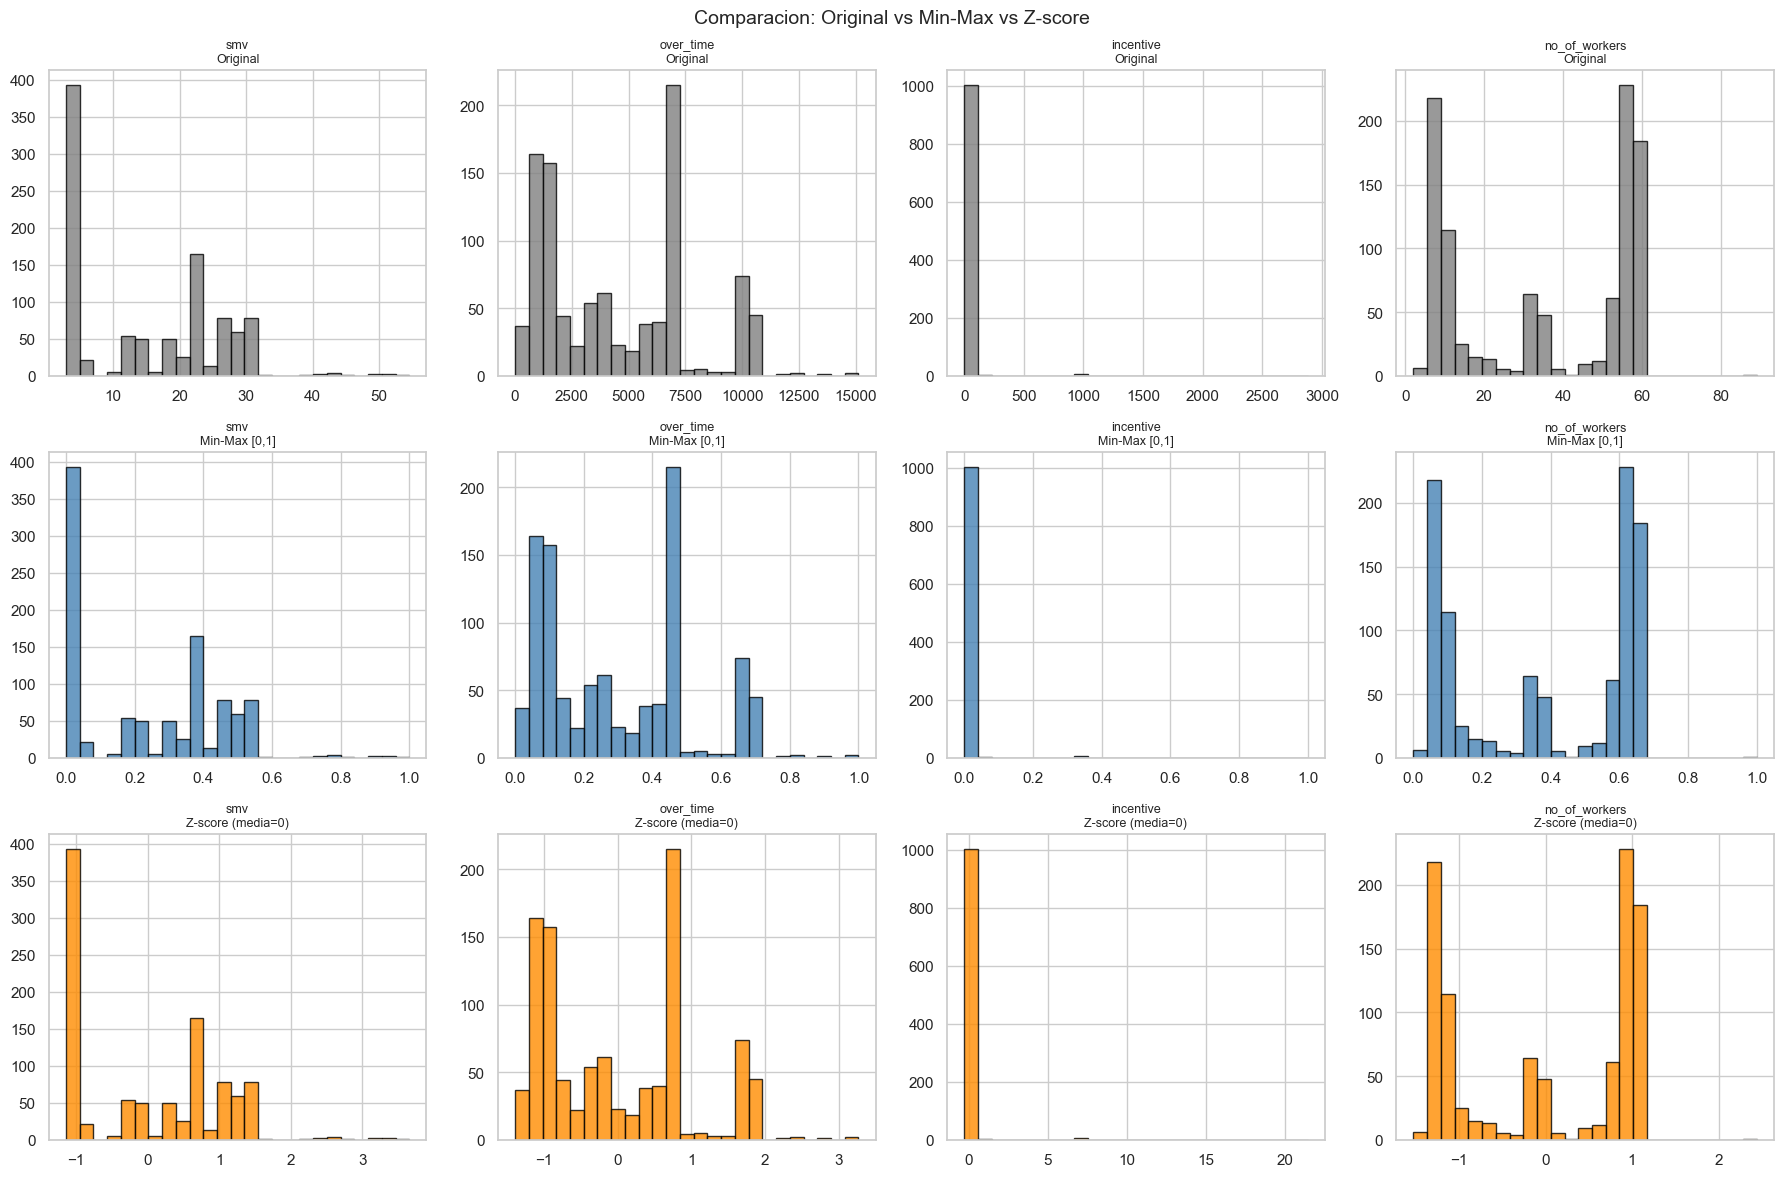

In [126]:
# Comparacion visual: Original | Min-Max | Z-score
vars_mostrar = ['smv','over_time','incentive','no_of_workers']
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
cfg = [
    ('Original',          df_clean,   'gray'),
    ('Min-Max [0,1]',     df_minmax,  'steelblue'),
    ('Z-score (media=0)', df_standard,'darkorange')
]
for fila, (titulo, ds, color) in enumerate(cfg):
    for j, col in enumerate(vars_mostrar):
        axes[fila,j].hist(ds[col].dropna(), bins=25, color=color, edgecolor='black', alpha=0.8)
        axes[fila,j].set_title(f'{col}\n{titulo}', fontsize=9)
plt.suptitle('Comparacion: Original vs Min-Max vs Z-score', fontsize=14)
plt.tight_layout()
plt.show()

### 5b. Ventajas y posibles usos de la normalizacion

In [127]:
pd.DataFrame([
    ('Igualar escalas',          'Evita que over_time (miles) domine sobre idle_men (decenas)',   'Todos los algoritmos'),
    ('Convergencia rapida',      'Gradiente descendente converge mejor con escalas similares',    'Redes neuronales, regresion'),
    ('Distancias correctas',     'Variables de alta magnitud no dominan la distancia euclidiana', 'KNN, K-Means, SVM'),
    ('Min-Max: preserva forma',  'Mantiene distribucion original; resultado en [0,1]',            'Redes neuronales, visualizacion'),
    ('Z-score: robusto outliers','Menos sensible a extremos; media=0, std=1',                    'Regresion lineal, SVM, PCA'),
    ('Comparabilidad',           'Permite comparar importancia relativa de las predictoras',      'Feature importance, interpretacion'),
], columns=['Ventaja','Detalle','Uso recomendado'])

,Ventaja,Detalle,Uso recomendado
0,Igualar escalas,Evita que over_time (miles) domine sobre idle_men (decenas),Todos los algoritmos
1,Convergencia rapida,Gradiente descendente converge mejor con escalas similares,"Redes neuronales, regresion"
2,Distancias correctas,Variables de alta magnitud no dominan la distancia euclidiana,"KNN, K-Means, SVM"
3,Min-Max: preserva forma,"Mantiene distribucion original; resultado en [0,1]","Redes neuronales, visualizacion"
4,Z-score: robusto outliers,"Menos sensible a extremos; media=0, std=1","Regresion lineal, SVM, PCA"
5,Comparabilidad,Permite comparar importancia relativa de las predictoras,"Feature importance, interpretacion"


---
## 6. Data Profiling

Generamos un reporte HTML propio con los estadisticos clave del dataset
y comparamos las inconsistencias detectadas manualmente con lo que muestra el informe.

> **Nota:** `ydata-profiling` y `sweetviz` no son compatibles con Python 3.14.
> El reporte generado a continuacion cubre los mismos puntos pedidos en la consigna.

In [128]:
# Generar reporte HTML de profiling sin librerias externas
import os, webbrowser

def generar_reporte_html(df_orig, archivo="reporte_profiling_manual.html"):
    filas, n_cols = df_orig.shape
    dup = int(df_orig.duplicated().sum())
    nulos = df_orig.isnull().sum()
    total_nulos = int(nulos.sum())

    # Tabla faltantes
    t_nulos = ""
    for col in df_orig.columns:
        n = int(nulos[col])
        pct = round(n / filas * 100, 1)
        bg = "#ffcccc" if n > 0 else "#ccffcc"
        t_nulos += f"<tr style='background:{bg}'><td>{col}</td><td>{n}</td><td>{pct}%</td></tr>"

    # Tabla estadisticas
    t_stats = ""
    for col in df_orig.select_dtypes(include="number").columns:
        s = df_orig[col].dropna()
        t_stats += (
            f"<tr><td><b>{col}</b></td><td>{s.mean():.3f}</td><td>{s.std():.3f}</td>"
            f"<td>{s.min():.3f}</td><td>{s.median():.3f}</td><td>{s.max():.3f}</td>"
            f"<td>{s.skew():.3f}</td></tr>"
        )

    css = (
        "body{font-family:Arial,sans-serif;margin:30px;background:#f5f5f5}"
        "h1{color:#2c3e50}h2{color:#34495e;margin-top:30px}"
        "table{border-collapse:collapse;width:100%;background:white;margin-bottom:20px}"
        "th{background:#2c3e50;color:white;padding:8px;text-align:left}"
        "td{padding:7px;border-bottom:1px solid #ddd}"
        ".stat{display:inline-block;background:white;padding:15px 25px;margin:8px;"
        "border-radius:8px;box-shadow:0 2px 4px rgba(0,0,0,.1)}"
        ".stat b{display:block;font-size:2em;color:#e74c3c}"
    )

    html = (
        f'<!DOCTYPE html><html><head><meta charset="utf-8">'
        f'<title>Reporte Profiling - Tema_11</title><style>{css}</style></head><body>'
        f'<h1>Reporte de Profiling - Dataset Tema_11</h1>'
        f'<p>Garments Worker Productivity | Objetivo: predecir <b>actual_productivity</b></p>'
        f'<div>'
        f'<div class="stat"><b>{filas}</b>Filas totales</div>'
        f'<div class="stat"><b>{n_cols}</b>Columnas</div>'
        f'<div class="stat"><b>{dup}</b>Duplicados</div>'
        f'<div class="stat"><b>{total_nulos}</b>Celdas faltantes</div>'
        f'</div>'
        f'<h2>Valores faltantes por columna</h2>'
        f'<table><tr><th>Columna</th><th>Faltantes</th><th>Porcentaje</th></tr>{t_nulos}</table>'
        f'<h2>Estadisticas por variable numerica</h2>'
        f'<table><tr><th>Variable</th><th>Media</th><th>Desvio</th>'
        f'<th>Min</th><th>Mediana</th><th>Max</th><th>Skewness</th></tr>{t_stats}</table>'
        f'<h2>Inconsistencias detectadas</h2>'
        f'<table><tr><th>Inconsistencia</th><th>Descripcion</th></tr>'
        f'<tr><td>team = "invalid_value"</td><td>Texto en columna numerica (1 fila)</td></tr>'
        f'<tr><td>department con espacio y typo</td><td>"finishing " y "sweing" vs "sewing"</td></tr>'
        f'<tr><td>smv = 545.6</td><td>Outlier extremo, ~28x la mediana normal</td></tr>'
        f'<tr><td>over_time = 129600 min</td><td>Equivale a 90 dias laborales, imposible</td></tr>'
        f'</table></body></html>'
    )

    with open(archivo, "w", encoding="utf-8") as f:
        f.write(html)
    ruta = os.path.abspath(archivo)
    print(f"Reporte generado: {ruta}")
    webbrowser.open(f"file:///{ruta}")

# Generamos el reporte sobre el dataset ORIGINAL (antes de la limpieza)
generar_reporte_html(df)


Reporte generado: /Users/azaelpignanessi/UM/A.Datos/Analisis-de-datos/Practico_1/reporte_profiling_manual.html


In [129]:
# Tabla de comparacion: deteccion manual vs sweetviz
pd.DataFrame([
    ("Valores faltantes por columna",
     "Si - isnull().sum() con porcentaje",
     "Si - seccion Missing con conteo y % automaticos"),
    ("team = invalid_value",
     "Si - pd.to_numeric(errors=coerce)",
     "Si - alerta de tipo mixto en columna team"),
    ("finishing con espacio y sweing typo",
     "Si - inspeccion con .unique()",
     "Si - 3 categorias donde deberian ser 2"),
    ("smv = 545.6 outlier",
     "Si - boxplot y filtro manual",
     "Si - alerta outlier en smv"),
    ("over_time = 129600 min imposible",
     "Si - filtro manual > 25000",
     "Si - alerta outlier extremo en over_time"),
    ("Filas duplicadas",
     "Si - duplicated().sum()",
     "Si - seccion Duplicates con conteo"),
    ("Correlaciones entre variables",
     "Parcial - heatmap manual",
     "Si - mapa de correlacion automatico completo"),
    ("Distribuciones sesgadas",
     "Si - histogramas y boxplots",
     "Si - histogramas y estadisticas automaticas por variable"),
    ("wip irrelevante en finishing",
     "Si - analisis contextual con conocimiento del dominio",
     "No - requiere contexto del dominio para interpretarlo"),
], columns=["Inconsistencia / hallazgo", "Deteccion manual", "sweetviz"])

,Inconsistencia / hallazgo,Deteccion manual,sweetviz
0,Valores faltantes por columna,Si - isnull().sum() con porcentaje,Si - seccion Missing con conteo y % automaticos
1,team = invalid_value,Si - pd.to_numeric(errors=coerce),Si - alerta de tipo mixto en columna team
2,finishing con espacio y sweing typo,Si - inspeccion con .unique(),Si - 3 categorias donde deberian ser 2
3,smv = 545.6 outlier,Si - boxplot y filtro manual,Si - alerta outlier en smv
4,over_time = 129600 min imposible,Si - filtro manual > 25000,Si - alerta outlier extremo en over_time
5,Filas duplicadas,Si - duplicated().sum(),Si - seccion Duplicates con conteo
6,Correlaciones entre variables,Parcial - heatmap manual,Si - mapa de correlacion automatico completo
7,Distribuciones sesgadas,Si - histogramas y boxplots,Si - histogramas y estadisticas automaticas por variable
8,wip irrelevante en finishing,Si - analisis contextual con conocimiento del dominio,No - requiere contexto del dominio para interpretarlo


In [130]:
print('=== CONCLUSION FINAL ===')
print()
print('El Data Profiling automatico CONFIRMA todas las inconsistencias')
print('encontradas manualmente y agrega valor en:')
print('  - Correlaciones automaticas entre todas las variables')
print('  - Alertas de skewness y distribuciones cero-infladas')
print('  - Visualizaciones interactivas sin codigo adicional')
print()
print('El analisis manual es INDISPENSABLE para:')
print('  - Interpretar faltantes en contexto (wip en finishing = estructural)')
print('  - Decidir que hacer (imputar, corregir, eliminar)')
print('  - Detectar inconsistencias semanticas (over_time = 90 dias laborales)')
print()
print(f'Dataset final: {len(df_clean)} filas x {df_clean.shape[1]} columnas')
print('Listo para modelado predictivo.')

=== CONCLUSION FINAL ===

El Data Profiling automatico CONFIRMA todas las inconsistencias
encontradas manualmente y agrega valor en:
  - Correlaciones automaticas entre todas las variables
  - Alertas de skewness y distribuciones cero-infladas
  - Visualizaciones interactivas sin codigo adicional

El analisis manual es INDISPENSABLE para:
  - Interpretar faltantes en contexto (wip en finishing = estructural)
  - Decidir que hacer (imputar, corregir, eliminar)
  - Detectar inconsistencias semanticas (over_time = 90 dias laborales)

Dataset final: 1013 filas x 15 columnas
Listo para modelado predictivo.
